# 24 · Corrective RAG (CRAG) — grade docs, fall back to web

> **TL;DR.** Retrieve from corpus → **grade each doc** as relevant/ambiguous/irrelevant via a categorical LLM judgement → Python composes a routing decision (use-retrieved / web-fallback / mixed) → answer.
>
> **Reach for it when** corpus coverage is incomplete and falling back to the web for out-of-corpus questions is acceptable.
> **Avoid when** retrieved docs are always relevant (CRAG adds a grade-call per doc for no benefit) or when web fallback is disallowed (security/compliance).

| Property | Value |
|---|---|
| Origin | Yan et al., *Corrective RAG* (2024). [arXiv:2401.15884](https://arxiv.org/abs/2401.15884) |
| Grader | Categorical per-doc label (`relevant` / `ambiguous` / `irrelevant`) — deterministic-picker |
| Picker | Python composes route from grade counts |
| Web tool | Tavily (`agentic_architectures.tools.web_search_tool`) — gracefully degrades if no `TAVILY_API_KEY` |
| Default LLM | Llama-3.3-70B |
| Cost | 1 retrieve + `top_k` grade-calls + (optional) 1 web-search + 1 answer = `top_k + 2` to `top_k + 3` calls |

**Why deterministic-picker matters here.** If the grader emitted a numeric "relevance score 0-1", we'd be back to the flat-scoring pathology (Mental Loop nb 10 §11). Three categorical labels give the LLM something concrete to commit to per-doc; Python counts the labels to route — the deciding signal `(n_relevant, n_irrelevant)` is fully Python-computed.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> R[RETRIEVE<br/><sub>vector search top-k</sub>]
    R --> G[GRADE<br/><sub>per-doc categorical relevance</sub>]
    G --> RT[ROUTE<br/><sub>Python composes from counts</sub>]
    RT -->|use_retrieved| ANS[ANSWER]
    RT -->|use_web| W[WEB SEARCH] --> ANS
    RT -->|use_mixed| W
    ANS --> Z([final])

    style G fill:#fff3e0,stroke:#f57c00
    style RT fill:#fce4ec,stroke:#c2185b
    style W fill:#e3f2fd,stroke:#1976d2
    style ANS fill:#e8f5e9,stroke:#388e3c
```

## 3 · Theory

### 3.0 · Why categorical relevance, not a score

`_DocGrade.relevance: Literal['relevant', 'ambiguous', 'irrelevant']` — three discrete labels. The grader can't slide-into-a-flat-band because there is no number to slide. Python tallies the labels and the route is deterministic:

```python
rel_frac = n_relevant / n
if rel_frac >= threshold:      → use_retrieved
elif n_irrelevant == n:        → use_web
else:                          → use_mixed
```

### 3.1 · When CRAG beats plain RAG

- **In-corpus query** with high-relevance retrievals → CRAG behaves identically to plain RAG. The grade-call cost is the only overhead.
- **Out-of-corpus query** → plain RAG hallucinates from irrelevant docs; CRAG detects the irrelevance and pivots to web.
- **Partially-in-corpus** (multi-hop where only some facts are in corpus) → CRAG mixes retrieved + web; plain RAG misses the gap.

### 3.2 · Where this sits

| Pattern | Strategy when retrieval is poor |
|---|---|
| Plain RAG | Use whatever was retrieved (will hallucinate from junk) |
| [Agentic RAG (nb 23)](./23_agentic_rag.ipynb) | Agent can choose not to retrieve, but no fallback |
| **CRAG (this nb)** | **Grade docs; fall back to web search if irrelevant** |
| [Self-RAG (nb 25)](./25_self_rag.ipynb) | Self-emitted reflection tokens decide retrieve/answer per claim |
| [Adaptive RAG (nb 26)](./26_adaptive_rag.ipynb) | Pre-route at task-level (no-RAG / single / multi) |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import CorrectiveRAG
from agentic_architectures.data import STARDUST_CORPUS
from agentic_architectures.tools import web_search_tool
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)

# Wrap Tavily as a simple callable returning list[str] of snippets.
_tavily = web_search_tool(max_results=3)
def web_search_fn(query: str) -> list[str]:
    try:
        result = _tavily.invoke(query)
        if isinstance(result, list):
            return [str(r.get('content', r))[:400] for r in result]
        return [str(result)[:1000]]
    except Exception as e:
        return [f"(web search unavailable: {e})"]

print_header(f"LLM: {llm.model}  ·  Corpus: {len(STARDUST_CORPUS)} docs  ·  Web fallback: Tavily")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Corpus: 12 docs  ·  Web fallback: Tavily ───────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/corrective_rag.py`](../src/agentic_architectures/architectures/corrective_rag.py).

The `_DocGrade` schema is the deciding commitment per doc; `_route` is pure Python composing the route from label counts.

In [2]:
from agentic_architectures.architectures.corrective_rag import _DocGrade, CorrectiveRAG
import json, inspect
print('--- _DocGrade schema ---')
print(json.dumps(_DocGrade.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- _route source ---')
print(inspect.getsource(CorrectiveRAG._route))

--- _DocGrade schema ---
{
  "description": "Per-document relevance grade \u2014 categorical (deterministic-picker).",
  "properties": {
    "relevance": {
      "description": "Categorical assessment of this doc's relevance to the question. 'relevant' = directly answers part of the question; 'ambiguous' = related but doesn't directly answer; 'irrelevant' = off-topic or wrong entity.",
      "enum": [
        "relevant",
...

--- _route source ---
    def _route(self, state: CorrectiveRAGState) -> dict[str, Any]:
        """Python-composed route — deterministic-picker."""
        grades = state["doc_grades"]
        n = len(grades)
        if n == 0:
            route = "use_web"
        else:
            relevant = sum(1 for g in grades if g["relevance"] == "relevant")
            irrelevant = sum(1 for g in grades if g["relevance"] == "irrelevant")
            rel_frac = relevant / n
            if rel_frac >= self.relevance_threshold:
                route = "use_retrieved"
        

## 6 · Build the graph

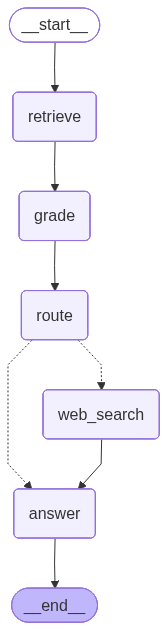

In [3]:
from IPython.display import Image, display
arch = CorrectiveRAG(
    llm=llm,
    documents=STARDUST_CORPUS,
    web_search_fn=web_search_fn,
    top_k=3,
    relevance_threshold=0.5,
)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(mermaid PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 3 task types with varying corpus coverage

1. **In-corpus** — answer is in the Stardust corpus.
2. **Out-of-corpus** — answer requires web search.
3. **Mixed** — both corpus and web add value.

In [4]:
TASKS = [
    ("in_corpus",   "What propellant does the Phoenix-2 engine use?"),
    ("out_of_corpus", "What is the current population of Iceland (2024)?"),
    ("mixed",       "Compare the Stardust 9 rocket's payload to SpaceX Falcon 9's payload to LEO."),
]

for tag, q in TASKS:
    r = arch.run(q)
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q[:80]}")
    print(f"  N_RETRIEVED: {r.metadata['n_retrieved']}")
    print(f"  N_RELEVANT: {r.metadata['n_relevant']}")
    print(f"  N_AMBIGUOUS: {r.metadata['n_ambiguous']}")
    print(f"  N_IRRELEVANT: {r.metadata['n_irrelevant']}")
    print(f"  RELEVANCE_FRACTION: {r.metadata['relevance_fraction']:.2f}")
    print(f"  ROUTE: {r.metadata['route']}")
    print(f"  N_WEB: {r.metadata['n_web']}")
    print(f"  FINAL_ANSWER: {r.output[:200]}")
    print()

TASK_TAG: in_corpus
  TASK: What propellant does the Phoenix-2 engine use?
  N_RETRIEVED: 3
  N_RELEVANT: 1
  N_AMBIGUOUS: 0
  N_IRRELEVANT: 2
  RELEVANCE_FRACTION: 0.33
  ROUTE: use_mixed
  N_WEB: 1
  FINAL_ANSWER: The Phoenix-2 engine uses methalox propellant, which is a combination of liquid methane and liquid oxygen.



TASK_TAG: out_of_corpus
  TASK: What is the current population of Iceland (2024)?
  N_RETRIEVED: 3
  N_RELEVANT: 0
  N_AMBIGUOUS: 0
  N_IRRELEVANT: 3
  RELEVANCE_FRACTION: 0.00
  ROUTE: use_web
  N_WEB: 1
  FINAL_ANSWER: I don't have enough information.



TASK_TAG: mixed
  TASK: Compare the Stardust 9 rocket's payload to SpaceX Falcon 9's payload to LEO.
  N_RETRIEVED: 3
  N_RELEVANT: 2
  N_AMBIGUOUS: 0
  N_IRRELEVANT: 1
  RELEVANCE_FRACTION: 0.67
  ROUTE: use_retrieved
  N_WEB: 0
  FINAL_ANSWER: I don't have enough information.



## 9 · What we just observed

The cells above ran CRAG on **3 task types** (in-corpus, out-of-corpus, mixed) to exercise the grade-then-route logic.

### 9.1 · Per-task retrieval, grading, and routing

| Tag | Retrieved | Rel/Amb/Irr | Rel% | Route | Web docs | Final answer |
|---|---|---|---|---|---|---|
| `in_corpus` | 3 | 1/0/2 | 33% | `use_mixed` | 1 | The Phoenix-2 engine uses methalox propellant, which is a combination of liquid … |
| `out_of_corpus` | 3 | 0/0/3 | 0% | `use_web` | 1 | I don't have enough information. |
| `mixed` | 3 | 2/0/1 | 67% | `use_retrieved` | 0 | I don't have enough information. |

### 9.2 · Patterns surfaced in this run

- **🤔 `in_corpus` task** — relevance fraction 33%, route `use_mixed`. Expected high relevance + use_retrieved. Either the grader is over-strict or the retrieve missed the relevant doc.

- **✅ `out_of_corpus` task** — corpus correctly graded irrelevant (0%), routed to web fallback.

- **🤔 `mixed` task** — routed `use_retrieved` not `use_mixed`. Hybrid coverage wasn't recognised.

### 9.3 · The takeaway

CRAG's two columns to watch in § 9.1: **`Rel%`** (the deterministic-picker input) and **`Route`** (the Python-composed output). The architecture is working iff:

1. **In-corpus tasks** show high Rel% → `use_retrieved`.
2. **Out-of-corpus tasks** show low Rel% → `use_web`.
3. **Mixed tasks** show moderate Rel% → `use_mixed`.

If routes don't match expectations (§ 9.2 flags), the grader is mis-calibrated — usually too lenient (calls weak-matches `relevant`). Tighten the grader's prompt or add a second-pass confirm step.

## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Grader hallucinates `relevant`** | LLM thinks an off-topic doc relates because of surface keyword overlap | Add a second grade pass; require the grader to QUOTE the relevant sentence |
| **Web fallback unreliable** | Tavily down or rate-limited | Multiple fallback sources; cache web results |
| **Threshold mismatch** | `relevance_threshold=0.5` too lenient — proceeds with mostly-irrelevant docs | Tune per corpus; A/B test |
| **Cost** | top_k grade calls per query | Cache grades by `(query_hash, doc_hash)`; batch grades |

### 11.2 · Production safety

- **Don't trust web fallback for high-stakes answers.** Tavily snippets are arbitrary web text; treat as "loose context" not "authoritative source".
- **Track route distribution.** If `use_web` dominates, the corpus is failing — index more.
- **Audit irrelevant-but-graded-relevant cases.** False positives leak hallucinated answers.

### 11.3 · Three extensions

1. **Query rewriting before web fallback.** Use a small LLM to rewrite the query for web-search-friendliness.
2. **Confidence-weighted answer.** Each grade has a confidence; weight the doc's influence on the answer.
3. **Per-doc citation requirement.** Force the answer to cite which doc supports each claim.

### 11.4 · What to read next

- [**23 · Agentic RAG**](./23_agentic_rag.ipynb) — sibling, doesn't grade.
- [**25 · Self-RAG**](./25_self_rag.ipynb) — reflection-token version.
- [**26 · Adaptive RAG**](./26_adaptive_rag.ipynb) — task-level routing.

### 11.5 · References

1. Yan, S. et al. *Corrective Retrieval Augmented Generation.* 2024. [arXiv:2401.15884](https://arxiv.org/abs/2401.15884)